In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.getcwd()

'C:\\Users\\pmgho'

In [4]:
os.chdir("C:\\Users\\pmgho\\OneDrive\\Documents\\ML Capstone Project")

In [5]:
df = pd.read_csv('ushape.csv')
df

,X,Y,class
0,-0.3967,0.2780,0.0
1,-1.2291,0.5395,0.0
2,0.4358,-0.3515,1.0
3,0.3969,0.5070,0.0
4,-0.8205,-0.0117,0.0
...,...,...,...
95,-0.7738,-0.5853,0.0
96,-0.9056,0.3981,1.0
97,-1.0653,-0.3414,0.0
98,-0.7459,-0.0321,1.0


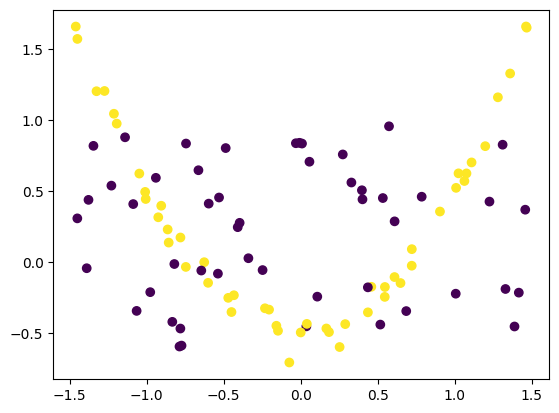

In [6]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [9]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.get_weights()

[array([[-1.9131114 ,  0.11370876, -1.2260107 ,  1.1059924 ,  0.01617304,
          1.07787   ,  0.56835043, -0.725846  ,  0.70631665, -0.26649284],
        [-1.9136984 , -0.9587566 , -0.9001708 ,  0.9139134 ,  0.37529388,
          0.21452114, -1.6018976 ,  0.3846836 , -0.9499995 ,  1.1247816 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.35452726,  0.6235468 ,  0.1900213 , -0.9086181 ,  0.7223941 ,
          0.51048046,  0.47004554, -0.06329239, -0.24229994,  0.6642906 ],
        [ 0.70849305,  0.3968093 , -0.13137883,  0.08152883, -0.44313422,
          0.00801052, -0.22255199, -0.0559656 ,  0.3371998 , -0.01043665],
        [-0.7010514 ,  0.36505193, -0.20073938, -0.1573429 , -0.3213133 ,
         -0.563589  ,  0.8987667 ,  0.01520005,  0.7305937 , -0.2116245 ],
        [-0.13816798, -0.01933032, -0.2734579 , -0.05950448,  0.01531543,
          0.68629247, -0.6750863 , -0.61850536, -0.27411005, -0.03323897],
        [ 0.33856

In [11]:
initial_weights = model.get_weights()

In [12]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [13]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[-0.49427024,  0.3247524 ,  0.23878431, -0.09891691, -0.23435128,
          0.2341735 ,  0.06527206, -0.1428712 ,  0.17572677,  0.96972424],
        [ 0.00441391, -0.45842025,  0.18361615, -0.94463193, -0.52529305,
          1.5236552 , -0.632841  , -0.57044894, -1.2635884 , -0.42579862]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.13530765, -0.12324398, -0.297117  ,  0.2676735 ,  0.00141403,
          0.08833566, -0.12025466,  0.05435814, -0.292265  , -0.02918329],
        [ 0.16189475,  0.21335313, -0.10270917, -0.5713059 ,  0.25275925,
          0.09679348,  0.06540284,  0.20035106,  0.4934655 ,  0.2947514 ],
        [ 0.6420754 ,  0.20927097,  0.14981537,  0.10111374, -0.45357975,
          0.32974058, -0.5641462 ,  0.20729639, -0.26393884,  0.10910247],
        [ 0.43369913, -0.5481163 ,  0.05046323, -0.2538209 ,  0.15024719,
         -0.16500849, -0.17453037,  0.14745082, -0.25145814,  0.2524273 ],
        [-0.23084

In [17]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [18]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.5250 - loss: 0.6947 - val_accuracy: 0.3500 - val_loss: 0.7035
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5500 - loss: 0.6936 - val_accuracy: 0.3500 - val_loss: 0.7035
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5250 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.7037
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5500 - loss: 0.6918 - val_accuracy: 0.3500 - val_loss: 0.7040
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5375 - loss: 0.6908 - val_accuracy: 0.3500 - val_loss: 0.7040
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5625 - loss: 0.6898 - val_accuracy: 0.3500 - val_loss: 0.7047
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5500 - loss: 0.6889 - val_accuracy: 0.3500 - val_loss: 0.7052
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5625 - loss: 0.6879 - val_accuracy: 0.3500 - val_loss

In [19]:
model.get_weights()

[array([[-0.6502567 ,  0.29509297,  0.24270214, -0.01187363, -0.15768833,
          0.14033099,  0.07094905, -0.24099872,  0.18677694,  1.1506969 ],
        [ 0.11218562, -0.5543079 ,  0.14081435, -1.0816097 , -0.6677568 ,
          1.6959325 , -0.51365405, -0.42468983, -1.4180614 , -0.32714468]],
       dtype=float32),
 array([-0.07370035,  0.04841868,  0.14780854,  0.03100434,  0.11885181,
         0.08950101, -0.10585348, -0.0892091 ,  0.00291837, -0.11764974],
       dtype=float32),
 array([[ 0.03371635, -0.14621793, -0.08525497,  0.42932633, -0.249573  ,
          0.16954252,  0.07425183, -0.02623079, -0.4333064 , -0.22590362],
        [ 0.21626507,  0.21335313, -0.06839499, -0.45770395,  0.26583824,
         -0.00150336,  0.04483867,  0.25231794,  0.4373668 ,  0.49474213],
        [ 0.6452881 ,  0.20927097,  0.04606478,  0.08867494, -0.56217927,
          0.4603189 , -0.555466  ,  0.34552196, -0.18451746,  0.21157517],
        [ 0.43222678, -0.5685401 ,  0.01144112, -0.2441771 , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


<Axes: >

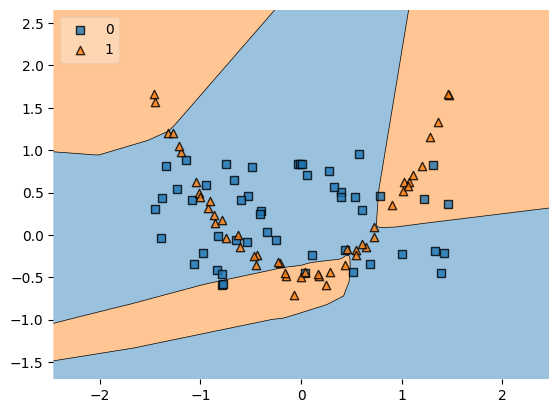

In [20]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [21]:
(np.random.randn(10,10)*0.01).min()

-0.020760023103467265

In [22]:
(np.random.randn(10,10)*0.01).max()

0.02444178687406876